In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Diabetes-dataset.xlsx")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (17000, 16)

Columns: ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']

First 5 rows:


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,0,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,0,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,1,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,1,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,0,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [2]:
print("Null values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nDiabetes value counts:\n", df['diabetes'].value_counts())

Null values:
 year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

Data types:
 year                      int64
gender                    int64
age                     float64
location                 object
race:AfricanAmerican      int64
race:Asian                int64
race:Caucasian            int64
race:Hispanic             int64
race:Other                int64
hypertension              int64
heart_disease             int64
smoking_history          object
bmi                     float64
hbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
dtype: object

Diabetes value c

# Preprocessing & Encoding

In [3]:
from sklearn.preprocessing import LabelEncoder

# Drop columns not useful for prediction
df_model = df.drop(columns=['year', 'location'])

# Encode smoking_history (text → numbers)
le = LabelEncoder()
df_model['smoking_history'] = le.fit_transform(df_model['smoking_history'])

print("Smoking history encoding map:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

print("\nProcessed data shape:", df_model.shape)
print("\nFirst 3 rows:")
df_model.head(3)

Smoking history encoding map:
  No Info → 0
  current → 1
  ever → 2
  former → 3
  never → 4
  not current → 5

Processed data shape: (17000, 14)

First 3 rows:


,gender,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,0,32.0,0,0,0,0,1,0,0,4,27.32,5.0,100,0
1,0,29.0,0,1,0,0,0,0,0,4,19.95,5.0,90,0
2,1,18.0,0,0,0,0,1,0,0,4,23.76,4.8,160,0


In [4]:
X = df_model.drop(columns=['diabetes'])
y = df_model['diabetes']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (17000, 13)
Target shape: (17000,)

Feature columns: ['gender', 'age', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level']


# Train Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 13600
Testing samples: 3400


# Train Random Forest Model

In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,    # 100 trees
    max_depth=10,        # prevent overfitting
    random_state=42,
    n_jobs=-1            # use all CPU cores, trains faster
)

model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


# Evaluate the Model

Accuracy: 90.76 %

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1700
           1       0.91      0.91      0.91      1700

    accuracy                           0.91      3400
   macro avg       0.91      0.91      0.91      3400
weighted avg       0.91      0.91      0.91      3400



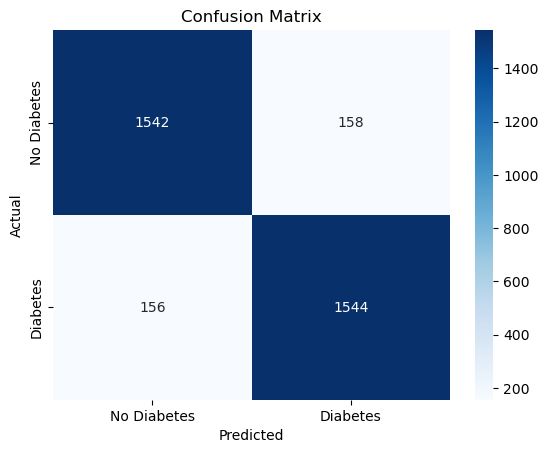

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [8]:
import joblib

joblib.dump(model, 'diabetes_model.pkl')
joblib.dump(le, 'smoking_encoder.pkl')

print("Model saved as diabetes_model.pkl")
print("Encoder saved as smoking_encoder.pkl")

Model saved as diabetes_model.pkl
Encoder saved as smoking_encoder.pkl


                 Feature  Importance
11           hbA1c_level    0.390456
12   blood_glucose_level    0.282163
1                    age    0.166951
10                   bmi    0.082594
7           hypertension    0.032069
9        smoking_history    0.018662
8          heart_disease    0.018374
0                 gender    0.003733
5          race:Hispanic    0.001133
2   race:AfricanAmerican    0.001010
6             race:Other    0.000978
4         race:Caucasian    0.000974
3             race:Asian    0.000902


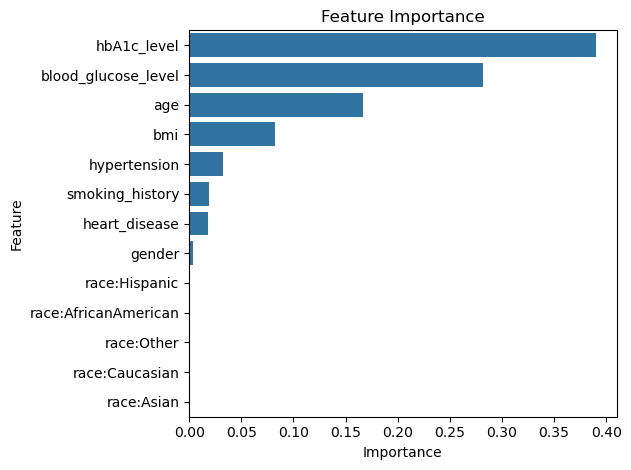

In [9]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

# Plot
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()